<a href="https://colab.research.google.com/github/PHYS-3510-SPRING-2026/hello-world-JeremyDail/blob/main/22_Random_walk_revisited_in_OOP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 22: Object-Oriented Random Walks

## Learning Objectives
By the end of this module you should be able to:
1. Read and trace through a class hierarchy you did not write yourself
2. Identify which methods are inherited vs. overridden in a child class
3. Explain what `_get_steps`, `get_walk`, `get_endpoints`, and `get_distances` compute, including the shape of the array each returns
4. Instantiate `LatticeWalk` objects in 1D, 2D, and 3D and compare their distance distributions
5. Plot a single 2D trajectory and a scatter plot of multiple endpoints using `LatticeWalk` methods

---

## Background

In Modules 18 and 19 we built random-walk simulations from scratch using NumPy arrays. Now we revisit the same problem using **Object-Oriented Programming** from Module 21.

The following two classes are adapted from the textbook's open-source code. Rather than writing them from scratch, the task here is to *read*, *understand*, and *use* them — a crucial skill when working with any scientific library.

The class hierarchy is:

```
RandomWalk          ← base class (abstract skeleton)
    └── LatticeWalk ← concrete implementation on a D-dimensional cubic lattice
```

Key design choice: the base class defines the high-level algorithms (`get_walk`, `get_endpoints`, `get_distances`) while the subclass only defines *how to generate a single step*. This makes it easy to swap in different step statistics without rewriting the analysis code.

---

## Setup

Run the cell below to define both classes. You will use them throughout the module.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

class RandomWalk():
    def __init__(self, dimension=1):
        self.rng = np.random.default_rng()
        self.D   = dimension
        self.r0  = np.zeros((self.D, 1))

    def _get_steps(self, N):
        # Placeholder — child classes override this.
        return np.zeros((self.D, N))

    def get_walk(self, N):
        return np.append(self.r0, np.cumsum(self._get_steps(N), axis=1), axis=1)

    def get_endpoints(self, M, N):
        return np.array([self.get_walk(N)[:, -1] for m in range(M)]).transpose()

    def get_distances(self, M, N):
        return np.sqrt(np.sum(self.get_endpoints(M, N)**2, axis=0))


class LatticeWalk(RandomWalk):
    def __init__(self, dimension=1):
        super().__init__(dimension)
        M = np.eye(self.D)
        self.basis  = [M[:, n] for n in range(self.D)]
        self.basis += [-M[:, n] for n in range(self.D)]

    def _get_steps(self, N):
        return self.rng.choice(self.basis, size=N).transpose()

print("Classes defined successfully.")

Classes defined successfully.


---

## Part 1: Analyzing the `RandomWalk` Base Class

Before using these classes, we need to understand what each method computes and what shape of array it returns. Here $N$ is the number of steps, $M$ is the number of particles, and $D$ is the spatial dimension.

### Task 1 — Array shapes

> **Q1.1** — `_get_steps(N)` returns an array of shape `(D, N)`. What does each row represent? What does each column represent? For a single 3D particle taking 10 steps, draw a sketch of this array.

> **Q1.2** — `get_walk(N)` starts with `r0` (shape `(D, 1)`) and appends the cumulative sum along `axis=1`. What does `np.cumsum(..., axis=1)` do here? What is the shape of `get_walk(N)`?

> **Q1.3** — `get_endpoints(M, N)` loops over $M$ particles, takes each walk's last column `[:, -1]`, and transposes the result. What shape does it return? Which axis is particles, which is coordinates?

> **Q1.4** — `get_distances(M, N)` squares the coordinates, sums along `axis=0`, and takes the square root. What does `axis=0` collapse? What shape does `get_distances` return?

In [4]:
# Verify your answers by checking shapes
walk_3d = LatticeWalk(3)

steps     = walk_3d._get_steps(10)
traj      = walk_3d.get_walk(10)
endpoints = walk_3d.get_endpoints(5, 10)
distances = walk_3d.get_distances(5, 10)

print(f"_get_steps(10)         shape: {steps.shape}       <- expect (3, 10)")
print(f"get_walk(10)           shape: {traj.shape}      <- expect (3, 11)")
print(f"get_endpoints(5, 10)   shape: {endpoints.shape}     <- expect (3, 5)")
print(f"get_distances(5, 10)   shape: {distances.shape}         <- expect (5,)")

_get_steps(10)         shape: (3, 10)       <- expect (3, 10)
get_walk(10)           shape: (3, 11)      <- expect (3, 11)
get_endpoints(5, 10)   shape: (3, 5)     <- expect (3, 5)
get_distances(5, 10)   shape: (5,)         <- expect (5,)


*Your answers to Q1.1, Q1.2, Q1.3, and Q1.4:*
Q1.1: Each row represents one coordinate direction like x, y, and z. Each column represents one step taken by a particle. For a 3D particle that takes 10 steps, the array would have 3 rows and 10 columns.
Q1.2 np.cumsum(..., axis = 1) adds up the steps across each row from left to right. This gives the particle's position after each step. The shape of get_walk(N) is (D,N+1) because it includes the starting point.
Q1.3: get_endpoints(M,N) returns shape (D,M). The rows are the coordinates and the columns are different particles.
Q1.4: axis=0 collapses the coordinate rows by combining x,y,and z values for each particle. The result is a 1D array with shape (M,).

---

## Part 2: Analyzing the `LatticeWalk` Subclass

### Task 2 — Understand `basis` and `_get_steps`

`LatticeWalk` overrides `_get_steps` to make real random steps on a D-dimensional cubic lattice.

> **Q2.1** — In `LatticeWalk.__init__`, `M = np.eye(self.D)` creates an identity matrix. What does `M[:, n]` give for a 3D walk? List all 6 vectors that end up in `self.basis` for `D=3`.

> **Q2.2** — In `_get_steps`, `self.rng.choice(self.basis, size=N)` picks $N$ random basis vectors. The result is shape `(N, D)`, so `.transpose()` makes it `(D, N)`. Why must this match the output shape of the base class's placeholder method?

> **Q2.3** — Why doesn't `LatticeWalk` need to define `get_walk`, `get_endpoints`, or `get_distances`?

In [5]:
# Inspect the basis vectors for a 2D and 3D walker
walk_2d = LatticeWalk(2)
walk_3d = LatticeWalk(3)

print("2D basis vectors (expect 4):")
for v in walk_2d.basis:
    print(" ", v)

print("\n3D basis vectors (expect 6):")
for v in walk_3d.basis:
    print(" ", v)

2D basis vectors (expect 4):
  [1. 0.]
  [0. 1.]
  [-1. -0.]
  [-0. -1.]

3D basis vectors (expect 6):
  [1. 0. 0.]
  [0. 1. 0.]
  [0. 0. 1.]
  [-1. -0. -0.]
  [-0. -1. -0.]
  [-0. -0. -1.]


*Your answers to Q2.1, Q2.2, and Q2.3:*
Q2.1: For a 3D walk, M[:,n] gives one column of the identity matrix. The six basis vectors are [1,0,0], [0,1,0], [0,0,1],[-1,0,0], [0,-1,0],[0,0,-1].
Q2.2: It has to match the base class shape because get_walk() expects steps to be arranged as (D,N). If the shape were different, the cumulative sum and append operations would not line up correctly.
Q2.3: LatticeWalk doesn't need to define those methods because it inherits them from RandomWalk. It changes how the random steps are created.

---

## Part 3: Using `LatticeWalk` Objects

### Task 3 — Distance distributions in 1D, 2D, and 3D

> **Q3.1** — Create three walkers — `lattice_1d`, `lattice_2d`, `lattice_3d` — and plot histograms of the distance distribution for `M=10000` particles after `N=1000` steps. Put the three histograms on the same figure (three subplots). Use `bins=20`.

> **Q3.2** — The root-mean-square distance from the origin should be $\sqrt{N}$ regardless of dimension. Compute and print `np.mean(distances**2)**0.5` for each dimension and verify this claim.

RMS distance 1D: 31.56  (expect ~31.62)
RMS distance 2D: 31.71  (expect ~31.62)
RMS distance 3D: 31.65  (expect ~31.62)


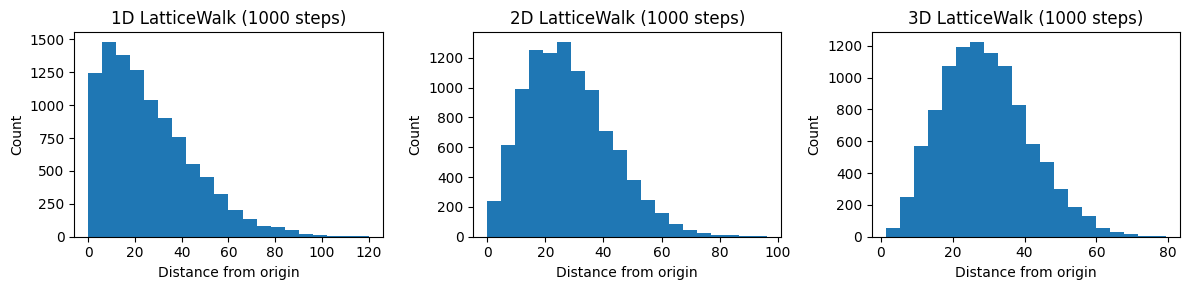

In [6]:
lattice_1d = LatticeWalk(1)
lattice_2d = LatticeWalk(2)
lattice_3d = LatticeWalk(3)

Nstep     = 1000
Nparticle = 10000

d1 = lattice_1d.get_distances(Nparticle, Nstep)
d2 = lattice_2d.get_distances(Nparticle, Nstep)
d3 = lattice_3d.get_distances(Nparticle, Nstep)

print(f"RMS distance 1D: {np.mean(d1**2)**0.5:.2f}  (expect ~{Nstep**0.5:.2f})")
print(f"RMS distance 2D: {np.mean(d2**2)**0.5:.2f}  (expect ~{Nstep**0.5:.2f})")
print(f"RMS distance 3D: {np.mean(d3**2)**0.5:.2f}  (expect ~{Nstep**0.5:.2f})")

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, d, dim in zip(axes, [d1, d2, d3], ['1D', '2D', '3D']):
    ax.hist(d, bins=20)
    ax.set_xlabel('Distance from origin')
    ax.set_ylabel('Count')
    ax.set_title(f'{dim} LatticeWalk ({Nstep} steps)')
plt.tight_layout()
plt.show()

*Your answers to Q3.1 and Q3.2:*
Q3.1: The three histograms show the distance distributions for 1D,2D, and 3D random walks. The exact shapes look different because distance is measured differently epending on the number of dimensions.
Q3.2: The RMS distances should all be near sqrt(1000), which is about 31.62. This supports the idea that the root-mean-square distance depends mainly on the number of steps, not the dimension.

---

## Part 4: Trajectory and Scatter Plots in 2D

### Task 4 — Plot a single 2D trajectory

`get_walk(N)` returns a `(D, N+1)` array. For a 2D walker, row 0 is the $x$ trajectory and row 1 is the $y$ trajectory.

> **Q4.1** — Use `lattice_2d.get_walk(200)` to generate a single 200-step trajectory. Plot $x$ vs $y$ as a line, mark the start with a green dot and the end with a red dot.

> **Q4.2** — Run the cell 5 times. Do the trajectories ever look the same? Does the endpoint ever return close to the origin?

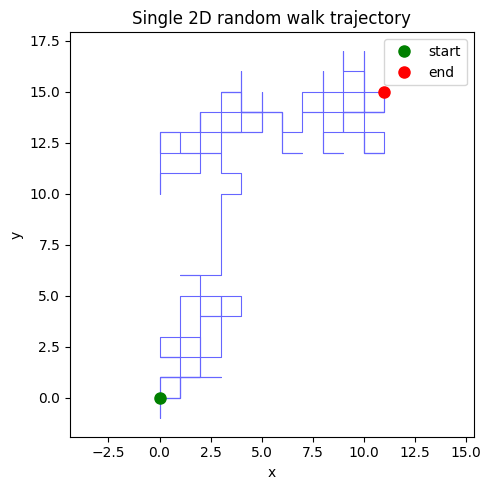

In [7]:
walk = lattice_2d.get_walk(200)   # shape (2, 201)

x = walk[0, :]
y = walk[1, :]

plt.figure(figsize=(5, 5))
plt.plot(x, y, 'b-', alpha=0.6, linewidth=0.8)
plt.plot(x[0],  y[0],  'go', ms=8, label='start')
plt.plot(x[-1], y[-1], 'ro', ms=8, label='end')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Single 2D random walk trajectory')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

*Your answers to Q4.1 and Q4.2:*
Q4.1: The plot shows one 200-step random walk in 2D. The green dot is the starting position, and the red dot is the ending position.
Q4.2: The trajectories don't look the same each time because the steps are randomly chosen. Sometimes the endpoint can be close to the origin upon return, but it doesn't always happen.

---

### Task 5 — Scatter plot of endpoints in 2D

`get_endpoints(M, N)` returns a `(D, M)` array. For a 2D walker, row 0 gives all $x$ endpoints and row 1 gives all $y$ endpoints.

> **Q5.1** — Generate endpoints for `M=5000` particles after `N=500` steps. Make a scatter plot of $x$ vs $y$ endpoints using `plt.scatter(..., alpha=0.1, s=2)`. Describe the shape you see.

> **Q5.2** — Where is the density highest? Why? Does this match the random-walk theory from Module 19?

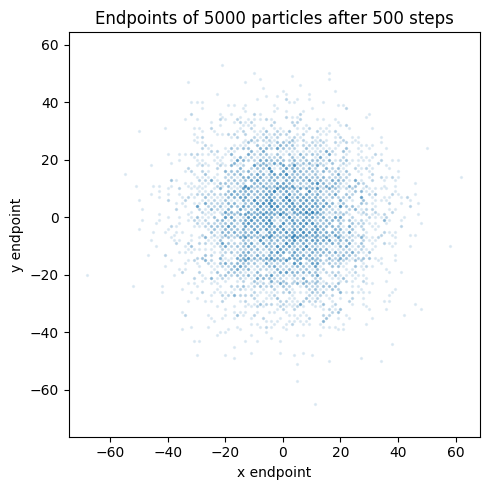

In [9]:
endpoints = lattice_2d.get_endpoints(5000, 500)   # shape (2, 5000)

xe = endpoints[0, :]
ye = endpoints[1, :]

plt.figure(figsize=(5, 5))
plt.scatter(xe, ye, alpha=0.1, s=2)
plt.xlabel('x endpoint')
plt.ylabel('y endpoint')
plt.title('Endpoints of 5000 particles after 500 steps')
plt.axis('equal')
plt.tight_layout()
plt.show()

*Your answers to Q5.1 and Q5.2:*
Q5.1: The scatter plot should form a circular cloud around the origin. This happens because the particles spread out in all directions over time.
Q5.2: The density is highest near the origin because most random walks stay close to where they started. This matches random walk theory because the endpoint distribution is centered near zero.

---

## Part 5: Exploration

### Task 6 — Custom step statistics

The power of OOP here is that we can change *only* `_get_steps` to try entirely different kinds of random walks, while reusing `get_walk`, `get_endpoints`, and `get_distances` unchanged.

> **Q6.1** — Create a `GaussianWalk` class that inherits from `RandomWalk` and overrides `_get_steps` to draw steps from a standard normal distribution: `self.rng.standard_normal((self.D, N))`. In words, how is this walk different from `LatticeWalk`?

> **Q6.2** — Compare the distance distribution of `GaussianWalk(2)` vs `LatticeWalk(2)` for the same `M` and `N`. Do they look similar or different? Why?

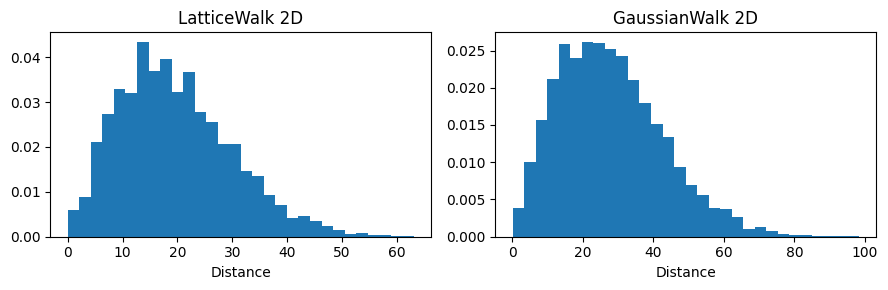

LatticeWalk  RMS: 22.18
GaussianWalk RMS: 31.62


In [10]:
class GaussianWalk(RandomWalk):
    def _get_steps(self, N):
        steps = self.rng.standard_normal((self.D, N))
        return steps

# Compare distance distributions
Mp, Np = 5000, 500

d_lattice  = LatticeWalk(2).get_distances(Mp, Np)
d_gaussian = GaussianWalk(2).get_distances(Mp, Np)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.hist(d_lattice,  bins=30, density=True)
ax1.set_title('LatticeWalk 2D')
ax1.set_xlabel('Distance')

ax2.hist(d_gaussian, bins=30, density=True)
ax2.set_title('GaussianWalk 2D')
ax2.set_xlabel('Distance')

plt.tight_layout()
plt.show()

print(f"LatticeWalk  RMS: {np.mean(d_lattice**2)**0.5:.2f}")
print(f"GaussianWalk RMS: {np.mean(d_gaussian**2)**0.5:.2f}")

*Your answers to Q6.1 and Q6.2:*
Q6.1: A GaussianWalk is different because its steps can be any normal distributed value, not just one unit in a lattice direction. This makes the path smoother and continuous compared to LatticeWalk.
Q6.2: The distributions look similar in shape overall because both are random walks spreading away from the origin. The Gaussian walk usually spreads farther because each coordinate gets a random normal step instead of one lattice step.

---

## Summary Questions

> **S1** — `_get_steps` in `RandomWalk` always returns zeros. Why define it at all instead of raising `NotImplementedError`? What is the design benefit?

> **S2** — `get_endpoints` uses a Python `for` loop over $M$ particles. For $M = 10000$ and $N = 1000$, this calls `get_walk` ten thousand times. Describe how you could rewrite `get_endpoints` to be fully vectorized (no Python loop), and estimate how much faster it might be.

> **S3** — In `LatticeWalk._get_steps`, why do we need `.transpose()` after `rng.choice`? What would go wrong without it?

> **S4** — Module 18 implemented random walks using plain NumPy arrays; Module 22 wraps the same logic in a class hierarchy. Give one concrete advantage and one concrete disadvantage of the OOP approach for this problem.

*Your answers:*

**S1:** getsteps is defined in RandomWalk so the parent class has a default version of the method, even if it returns only zeros. This lets the rest of the class methods like get walk, get endpoints, and get distances work without breaking. The design benefit is that subclasses only need to override get steps to create different types of random walks while reusing the same shared code.

**S2:** You could create all steps for all particles at once in a bigger NumPY array and then take the cumsum or final sum without using a loop. This would be faster because NumPy operations are vectorized.

**S3:** The transpose is needed because rng.choice gives the steps in shape (N,D), but the rest of the code expects (D,N). Without the transpose the coordinate and step axes would be flipped around and the calculations wouldn't match.

**S4:** One advantage of OOP is that different types of walks can share the same methods for trajectories, endpoints, and distances. A disadvantage could be that the code can be harder to understand because you have to find out which methods are inherited and which are overridden.